In [1]:
import cfgrib
import xarray as xr

In [9]:
filename="common_tryout_datasets/small_grid/grid-timeseries_sel_vars_2026_april.grib"

datasets_1940 = cfgrib.open_datasets(filename)

for i, d in enumerate(datasets_1940):
    print(f"--- Dataset {i} ---")
    print(list(d.data_vars))

--- Dataset 0 ---
['sp', 'tcc', 'u10', 'v10', 't2m']
--- Dataset 1 ---
['ssrd', 'tp']


/home/peter/anaconda3/envs/appmlenv/lib/python3.12/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/home/peter/anaconda3/envs/appmlenv/lib/python3.12/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwar

In [7]:
datasets_1940 = cfgrib.open_datasets("grid-timeseries_sel_vars_1940.grib")
print("Features time:", len(datasets_1940[0].time))
print("tp time:", len(datasets_1940[1].time))
print()
print("Features step:", datasets_1940[0].time.values[1] - datasets_1940[0].time.values[0])
print("tp step:", datasets_1940[1].time.values[1] - datasets_1940[1].time.values[0])

Features time: 8784
tp time: 732

Features step: 3600000000000 nanoseconds
tp step: 43200000000000 nanoseconds


c:\Users\Tradeshop35\anaconda3\envs\appmlenv\Lib\site-packages\cfgrib\xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
c:\Users\Tradeshop35\anaconda3\envs\appmlenv\Lib\site-packages\cfgrib\xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


In [8]:
ds_tp = datasets_1940[1]
tp = ds_tp["tp"]  # shape: (732, 5, 5)

# De-accumulate: 
tp_deacc = tp.diff("time")

# negative values = reset points → put 0
tp_deacc = tp_deacc.clip(min=0)

print(tp_deacc)

<xarray.DataArray 'tp' (time: 731, step: 12, latitude: 5, longitude: 5)> Size: 877kB
array([[[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00],
    

In [9]:
ds_tp = datasets_1940[1]
tp = ds_tp["tp"]
print(tp)
print()
print(tp.dims)
print(tp.coords)

<xarray.DataArray 'tp' (time: 732, step: 12, latitude: 5, longitude: 5)> Size: 878kB
[219600 values with dtype=float32]
Coordinates:
  * time        (time) datetime64[ns] 6kB 1940-01-01T06:00:00 ... 1940-12-31T...
  * step        (step) timedelta64[ns] 96B 01:00:00 02:00:00 ... 12:00:00
    valid_time  (time, step) datetime64[ns] 70kB 1940-01-01T07:00:00 ... 1941...
  * latitude    (latitude) float64 40B 56.0 55.75 55.5 55.25 55.0
  * longitude   (longitude) float64 40B 12.0 12.25 12.5 12.75 13.0
    number      int64 8B 0
    surface     float64 8B 0.0
Attributes: (12/31)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      25
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_shortName:                           tp
    GRIB_totalNumbe

In [10]:
tp_df = tp.to_series().reset_index()
print(tp_df.head(20))
print(tp_df.columns)

                  time            step  latitude  longitude            tp
0  1940-01-01 06:00:00 0 days 01:00:00     56.00      12.00  4.768372e-07
1  1940-01-01 06:00:00 0 days 01:00:00     56.00      12.25  0.000000e+00
2  1940-01-01 06:00:00 0 days 01:00:00     56.00      12.50  0.000000e+00
3  1940-01-01 06:00:00 0 days 01:00:00     56.00      12.75  0.000000e+00
4  1940-01-01 06:00:00 0 days 01:00:00     56.00      13.00  0.000000e+00
5  1940-01-01 06:00:00 0 days 01:00:00     55.75      12.00  0.000000e+00
6  1940-01-01 06:00:00 0 days 01:00:00     55.75      12.25  0.000000e+00
7  1940-01-01 06:00:00 0 days 01:00:00     55.75      12.50  0.000000e+00
8  1940-01-01 06:00:00 0 days 01:00:00     55.75      12.75  0.000000e+00
9  1940-01-01 06:00:00 0 days 01:00:00     55.75      13.00  0.000000e+00
10 1940-01-01 06:00:00 0 days 01:00:00     55.50      12.00  0.000000e+00
11 1940-01-01 06:00:00 0 days 01:00:00     55.50      12.25  0.000000e+00
12 1940-01-01 06:00:00 0 days 01:00:00

In [11]:
tp_df["valid_time"] = tp_df["time"] + tp_df["step"]

tp_df["tp_hourly"] = tp_df.groupby(["time", "latitude", "longitude"])["tp"].diff()

tp_df["tp_hourly"] = tp_df["tp_hourly"].fillna(tp_df["tp"])

tp_df["tp_hourly"] = tp_df["tp_hourly"].clip(lower=0)

tp_df = tp_df[["valid_time", "latitude", "longitude", "tp_hourly"]].sort_values("valid_time")

print(tp_df.head(20))

            valid_time  latitude  longitude     tp_hourly
0  1940-01-01 07:00:00     56.00      12.00  4.768372e-07
24 1940-01-01 07:00:00     55.00      13.00  3.337860e-06
23 1940-01-01 07:00:00     55.00      12.75  8.106232e-06
22 1940-01-01 07:00:00     55.00      12.50  6.675720e-06
21 1940-01-01 07:00:00     55.00      12.25  1.430511e-06
20 1940-01-01 07:00:00     55.00      12.00  0.000000e+00
19 1940-01-01 07:00:00     55.25      13.00  0.000000e+00
17 1940-01-01 07:00:00     55.25      12.50  4.768372e-07
16 1940-01-01 07:00:00     55.25      12.25  0.000000e+00
15 1940-01-01 07:00:00     55.25      12.00  0.000000e+00
14 1940-01-01 07:00:00     55.50      13.00  0.000000e+00
13 1940-01-01 07:00:00     55.50      12.75  0.000000e+00
18 1940-01-01 07:00:00     55.25      12.75  4.768372e-07
11 1940-01-01 07:00:00     55.50      12.25  0.000000e+00
12 1940-01-01 07:00:00     55.50      12.50  0.000000e+00
2  1940-01-01 07:00:00     56.00      12.50  0.000000e+00
3  1940-01-01 

In [12]:
ds_features = datasets_1940[0]
df_features = ds_features.to_dataframe().reset_index()
df_features = df_features.rename(columns={"time": "valid_time"})

print(df_features.columns)
print(df_features["valid_time"].min(), "→", df_features["valid_time"].max())
print(" features:", len(df_features))

Index(['valid_time', 'latitude', 'longitude', 'number', 'step', 'surface',
       'valid_time', 'sp', 'tcc', 'u10', 'v10', 't2m'],
      dtype='object')
valid_time   1940-01-01
valid_time   1940-01-01
dtype: datetime64[ns] → valid_time   1940-12-31 23:00:00
valid_time   1940-12-31 23:00:00
dtype: datetime64[ns]
 features: 219600


In [13]:
df_features = ds_features.to_dataframe().reset_index()
df_features = df_features.rename(columns={"time": "valid_time"})

df_features = df_features[["valid_time", "latitude", "longitude", "sp", "tcc", "u10", "v10", "t2m"]]

print(df_features.columns)
print(df_features.head())

Index(['valid_time', 'valid_time', 'latitude', 'longitude', 'sp', 'tcc', 'u10',
       'v10', 't2m'],
      dtype='object')
  valid_time valid_time  latitude  longitude             sp       tcc  \
0 1940-01-01 1940-01-01      56.0      12.00  101743.484375  0.985992   
1 1940-01-01 1940-01-01      56.0      12.25  101687.484375  0.925629   
2 1940-01-01 1940-01-01      56.0      12.50  101552.484375  0.851105   
3 1940-01-01 1940-01-01      56.0      12.75  101284.484375  0.939819   
4 1940-01-01 1940-01-01      56.0      13.00  101080.484375  0.996674   

        u10       v10         t2m  
0 -3.432312 -7.159088  267.977661  
1 -2.850281 -6.402252  266.917114  
2 -2.054382 -4.979401  265.581177  
3 -1.250671 -4.790924  265.135864  
4 -0.644226 -4.691315  264.825317  


In [14]:
df_features = ds_features.to_dataframe().reset_index()

print(df_features.columns.tolist())

['time', 'latitude', 'longitude', 'number', 'step', 'surface', 'valid_time', 'sp', 'tcc', 'u10', 'v10', 't2m']


In [15]:
df_features = ds_features.to_dataframe().reset_index()
df_features = df_features[["valid_time", "latitude", "longitude", "sp", "tcc", "u10", "v10", "t2m"]]

print(df_features.columns.tolist())
print(df_features.head())

['valid_time', 'latitude', 'longitude', 'sp', 'tcc', 'u10', 'v10', 't2m']
  valid_time  latitude  longitude             sp       tcc       u10  \
0 1940-01-01      56.0      12.00  101743.484375  0.985992 -3.432312   
1 1940-01-01      56.0      12.25  101687.484375  0.925629 -2.850281   
2 1940-01-01      56.0      12.50  101552.484375  0.851105 -2.054382   
3 1940-01-01      56.0      12.75  101284.484375  0.939819 -1.250671   
4 1940-01-01      56.0      13.00  101080.484375  0.996674 -0.644226   

        v10         t2m  
0 -7.159088  267.977661  
1 -6.402252  266.917114  
2 -4.979401  265.581177  
3 -4.790924  265.135864  
4 -4.691315  264.825317  


In [16]:
import pandas as pd

df = pd.merge(df_features, tp_df, on=["valid_time", "latitude", "longitude"], how="inner")

print(df.columns.tolist())
print(df.shape)
print(df.head())

['valid_time', 'latitude', 'longitude', 'sp', 'tcc', 'u10', 'v10', 't2m', 'tp_hourly']
(219425, 9)
           valid_time  latitude  longitude             sp       tcc       u10  \
0 1940-01-01 07:00:00      56.0      12.00  102320.640625  0.951019 -2.564911   
1 1940-01-01 07:00:00      56.0      12.25  102261.640625  0.539001 -2.021942   
2 1940-01-01 07:00:00      56.0      12.50  102124.640625  0.142395 -1.299286   
3 1940-01-01 07:00:00      56.0      12.75  101860.640625  0.043152 -0.744598   
4 1940-01-01 07:00:00      56.0      13.00  101661.640625  0.000000 -0.421356   

        v10         t2m     tp_hourly  
0 -4.968643  267.761108  4.768372e-07  
1 -4.617081  266.438843  0.000000e+00  
2 -3.684464  264.911499  0.000000e+00  
3 -3.733292  263.700562  0.000000e+00  
4 -3.703995  262.265015  0.000000e+00  


In [17]:
print(df.shape)
print(df.dtypes)
print(df["valid_time"].min(), "→", df["valid_time"].max())
print("Grid points:", df.groupby(["latitude", "longitude"]).ngroups)
print(df.isna().sum())

(219425, 9)
valid_time    datetime64[ns]
latitude             float64
longitude            float64
sp                   float32
tcc                  float32
u10                  float32
v10                  float32
t2m                  float32
tp_hourly            float32
dtype: object
1940-01-01 07:00:00 → 1940-12-31 23:00:00
Grid points: 25
valid_time    0
latitude      0
longitude     0
sp            0
tcc           0
u10           0
v10           0
t2m           0
tp_hourly     0
dtype: int64


In [18]:
import numpy as np


df = df.sort_values(["valid_time", "latitude", "longitude"]).reset_index(drop=True)

# time features
df["hour"]      = df["valid_time"].dt.hour
df["dayofyear"] = df["valid_time"].dt.dayofyear
df["month"]     = df["valid_time"].dt.month

# Lag features per grid point
lags = [1, 3, 6, 12, 24, 48, 72]
vars_to_lag = ["t2m", "sp", "tcc", "u10", "v10"]

for var in vars_to_lag:
    for lag in lags:
        df[f"{var}_lag{lag}"] = df.groupby(["latitude", "longitude"])[var].shift(lag)

# Rolling averages per grid point
for var in vars_to_lag:
    df[f"{var}_roll24_mean"] = df.groupby(["latitude", "longitude"])[var].transform(lambda x: x.rolling(24).mean())

print(df.shape)
print(df.isna().sum().sum())

(219425, 52)
23625


In [19]:
# target: precipitation 24 hours ahead, per grid point
df["tp_target"] = df.groupby(["latitude", "longitude"])["tp_hourly"].shift(-24)

# Drop NaN από lags/rolling/target
df = df.dropna().copy()

y = np.log1p(df["tp_target"])

X = df.drop(columns=["valid_time", "tp_hourly", "tp_target"])

X = X[[col for col in X.columns if not col.startswith("tp")]]

n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

time_train = df["valid_time"].iloc[:train_end]
time_val   = df["valid_time"].iloc[train_end:val_end]
time_test  = df["valid_time"].iloc[val_end:]

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Train: (151917, 50)
Val:   (32554, 50)
Test:  (32554, 50)


In [20]:
from xgboost import XGBRegressor

# Weights
weights_train = 1 + 5000 * np.expm1(y_train)

model_grid = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_grid.fit(
    X_train,
    y_train,
    sample_weight=weights_train
)

print("Done!")

Done!


Grid XGBoost @ 17:00 - VAL
MAE: 0.00012951198732480407
RMSE: 0.00015079290719389538
Correlation: -0.10091890540486328


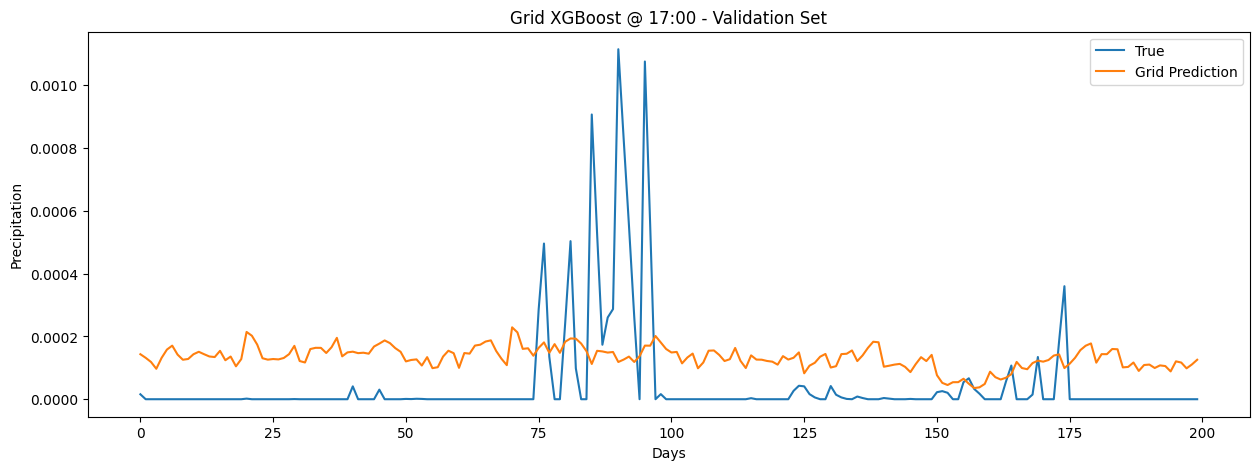

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    print(name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("Correlation:", corr)

pred_log_val = model_grid.predict(X_val)
pred_val = np.expm1(pred_log_val).clip(0)
y_val_tp = np.expm1(y_val)

mask_17_val = time_val.dt.hour == 17

evaluate_model(y_val_tp[mask_17_val], pred_val[mask_17_val.values], "Grid XGBoost @ 17:00 - VAL")

import matplotlib.pyplot as plt
plt.figure(figsize=(15,5))
plt.plot(y_val_tp[mask_17_val].values[:200], label="True")
plt.plot(pred_val[mask_17_val.values][:200], label="Grid Prediction")
plt.xlabel("Days")
plt.ylabel("Precipitation")
plt.title("Grid XGBoost @ 17:00 - Validation Set")
plt.legend()
plt.show()

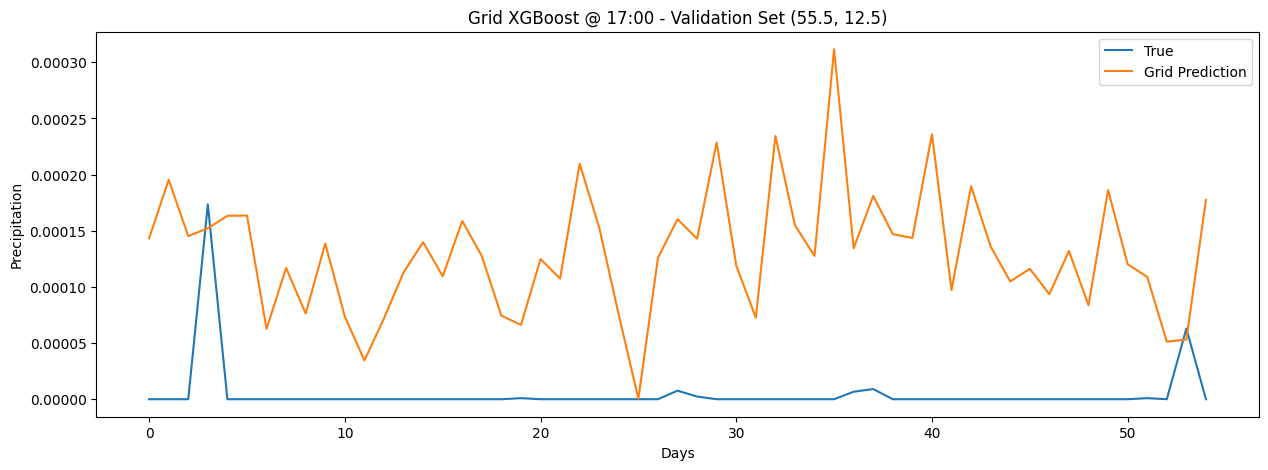

In [22]:
# central grid point (55.5, 12.5)
mask_17_val = (time_val.dt.hour == 17)
mask_point = (df.iloc[train_end:val_end]["latitude"] == 55.5) & \
             (df.iloc[train_end:val_end]["longitude"] == 12.5)

combined_mask = mask_17_val & mask_point.values

plt.figure(figsize=(15,5))
plt.plot(y_val_tp[combined_mask].values, label="True")
plt.plot(pred_val[combined_mask.values], label="Grid Prediction")
plt.xlabel("Days")
plt.ylabel("Precipitation")
plt.title("Grid XGBoost @ 17:00 - Validation Set (55.5, 12.5)")
plt.legend()
plt.show()

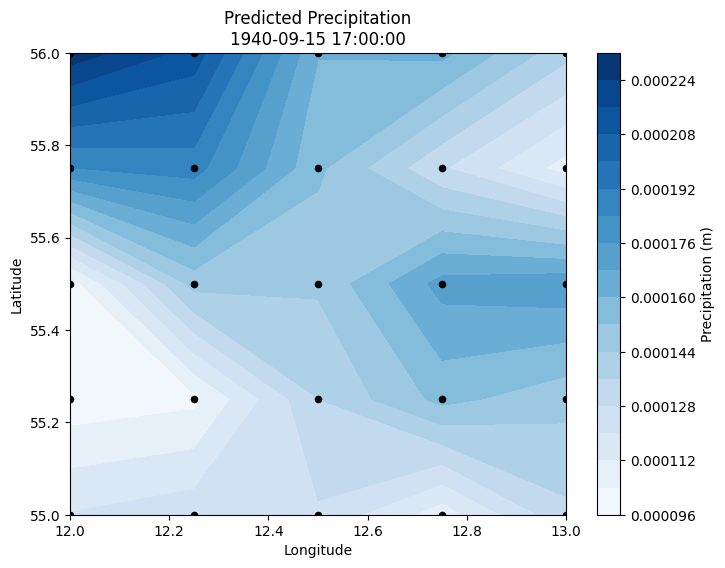

In [23]:
import matplotlib.pyplot as plt
import numpy as np

def plot_precip_map(model, X, df_full, target_datetime):
    """
    shows precipitation map for spesific time.
    target_datetime: π.χ. "1940-09-15 17:00:00"
    """
    # filtering for the spesific time 
    mask = df_full["valid_time"] == pd.Timestamp(target_datetime)
    X_map = X[mask.values]
    
    if len(X_map) == 0:
        print("Δεν βρέθηκαν δεδομένα για αυτή την ώρα")
        return
    
    # Prediction
    pred_log = model.predict(X_map)
    pred_tp = np.expm1(pred_log)
    
    # Lat/lon for the plot
    lats = df_full[mask]["latitude"].values
    lons = df_full[mask]["longitude"].values
    
    # Reshape σε 5x5 grid
    lat_unique = np.sort(np.unique(lats))[::-1]  # φθίνουσα σειρά
    lon_unique = np.sort(np.unique(lons))
    
    grid = np.zeros((len(lat_unique), len(lon_unique)))
    for i, lat in enumerate(lat_unique):
        for j, lon in enumerate(lon_unique):
            point_mask = (lats == lat) & (lons == lon)
            if point_mask.any():
                grid[i, j] = pred_tp[point_mask][0]
    
    # Plot
    plt.figure(figsize=(8, 6))
    plt.contourf(lon_unique, lat_unique, grid, cmap="Blues", levels=20)
    plt.colorbar(label="Precipitation (m)")
    plt.scatter(lons, lats, c="black", s=20, zorder=5)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(f"Predicted Precipitation\n{target_datetime}")
    plt.show()

# Χρήση
plot_precip_map(model_grid, X, df, "1940-09-15 17:00:00")

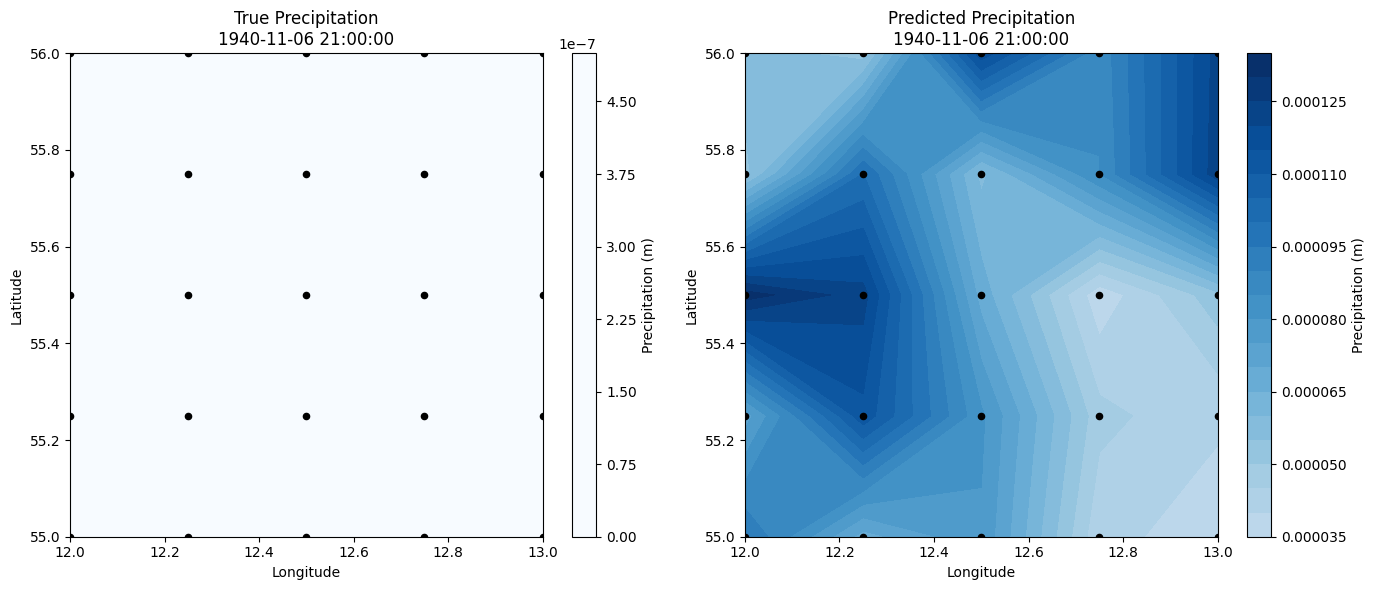

In [28]:
def plot_precip_map_comparison(model, X, df_full, target_datetime):
    
    mask = df_full["valid_time"] == pd.Timestamp(target_datetime)
    X_map = X[mask.values]
    
    pred_log = model.predict(X_map)
    pred_tp = np.expm1(pred_log).clip(0)
    true_tp = df_full[mask]["tp_target"].values  # ← πραγματική τιμή +24h
    
    lats = df_full[mask]["latitude"].values
    lons = df_full[mask]["longitude"].values
    lat_unique = np.sort(np.unique(lats))[::-1]
    lon_unique = np.sort(np.unique(lons))
    
    def make_grid(values):
        grid = np.zeros((len(lat_unique), len(lon_unique)))
        for i, lat in enumerate(lat_unique):
            for j, lon in enumerate(lon_unique):
                point_mask = (lats == lat) & (lons == lon)
                if point_mask.any():
                    grid[i, j] = values[point_mask][0]
        return grid
    
    vmin = 0
    vmax = max(pred_tp.max(), true_tp.max())
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    for ax, values, title in zip(axes, [true_tp, pred_tp], ["True", "Predicted"]):
        grid = make_grid(values)
        im = ax.contourf(lon_unique, lat_unique, grid, cmap="Blues", levels=20, vmin=vmin, vmax=vmax)
        ax.scatter(lons, lats, c="black", s=20, zorder=5)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_title(f"{title} Precipitation\n{target_datetime}")
        plt.colorbar(im, ax=ax, label="Precipitation (m)")
    
    plt.tight_layout()
    plt.show()

plot_precip_map_comparison(
    model_grid,
    X,
    df,
    str(time_test.iloc[100])
)

In [26]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor

param_dist = {
    "n_estimators": [200, 300, 500, 800],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 8],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "gamma": [0, 0.1, 0.3, 1]
}

tscv = TimeSeriesSplit(n_splits=3)

xgb = XGBRegressor(random_state=42)

random_search_grid = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_grid.fit(
    X_train,
    y_train,
    sample_weight=weights_train
)

print(random_search_grid.best_params_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
{'subsample': 0.6, 'n_estimators': 800, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.6}


In [112]:
best_model_grid = random_search_grid.best_estimator_

pred_log_val_best = best_model_grid.predict(X_val)
pred_val_best = np.expm1(pred_log_val_best).clip(0)
y_val_tp = np.expm1(y_val)

mask_17_val = time_val.dt.hour == 17

evaluate_model(y_val_tp[mask_17_val], pred_val_best[mask_17_val.values], "Tuned Grid XGBoost @ 17:00 - VAL")

# comparing with the previous
evaluate_model(y_val_tp[mask_17_val], pred_val[mask_17_val.values], "Baseline Grid XGBoost @ 17:00 - VAL")

Tuned Grid XGBoost @ 17:00 - VAL
MAE: 9.724404662847519e-05
RMSE: 0.00011660943465739015
Correlation: nan
Baseline Grid XGBoost @ 17:00 - VAL
MAE: 0.00012951198732480407
RMSE: 0.00015079290719389538
Correlation: -0.10091890540486328


c:\Users\Tradeshop35\anaconda3\envs\appmlenv\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Tradeshop35\anaconda3\envs\appmlenv\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [113]:
print("Pred min/max:", pred_val_best[mask_17_val.values].min(), pred_val_best[mask_17_val.values].max())
print("True min/max:", y_val_tp[mask_17_val].min(), y_val_tp[mask_17_val].max())

Pred min/max: 9.069438e-05 9.069438e-05
True min/max: 0.0 0.0011148453


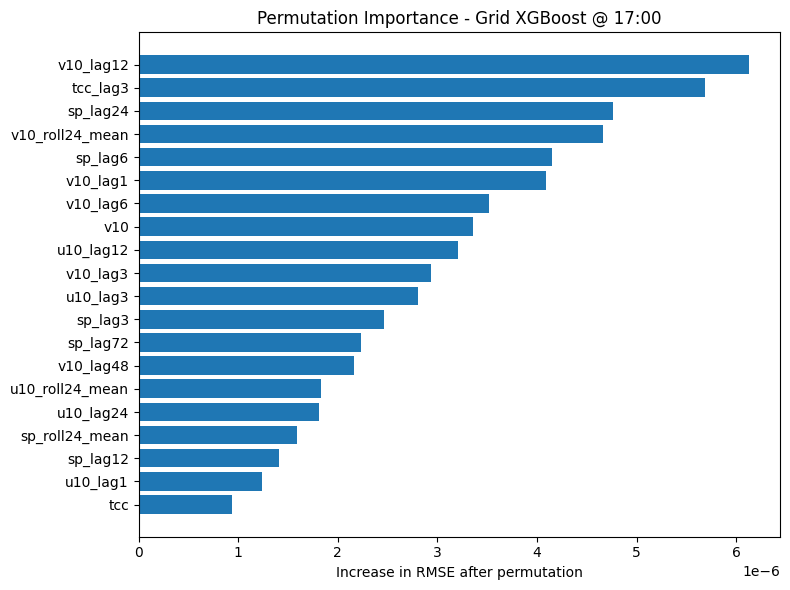

In [114]:
# Permutation Importance
from sklearn.inspection import permutation_importance
import pandas as pd

mask_17_val = time_val.dt.hour == 17

result = permutation_importance(
    model_grid,
    X_val[mask_17_val],
    y_val[mask_17_val],
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values("importance_mean", ascending=False)

top_n = 20
plt.figure(figsize=(8, 6))
plt.barh(
    importance_df["feature"].head(top_n)[::-1],
    importance_df["importance_mean"].head(top_n)[::-1]
)
plt.xlabel("Increase in RMSE after permutation")
plt.title("Permutation Importance - Grid XGBoost @ 17:00")
plt.tight_layout()
plt.show()

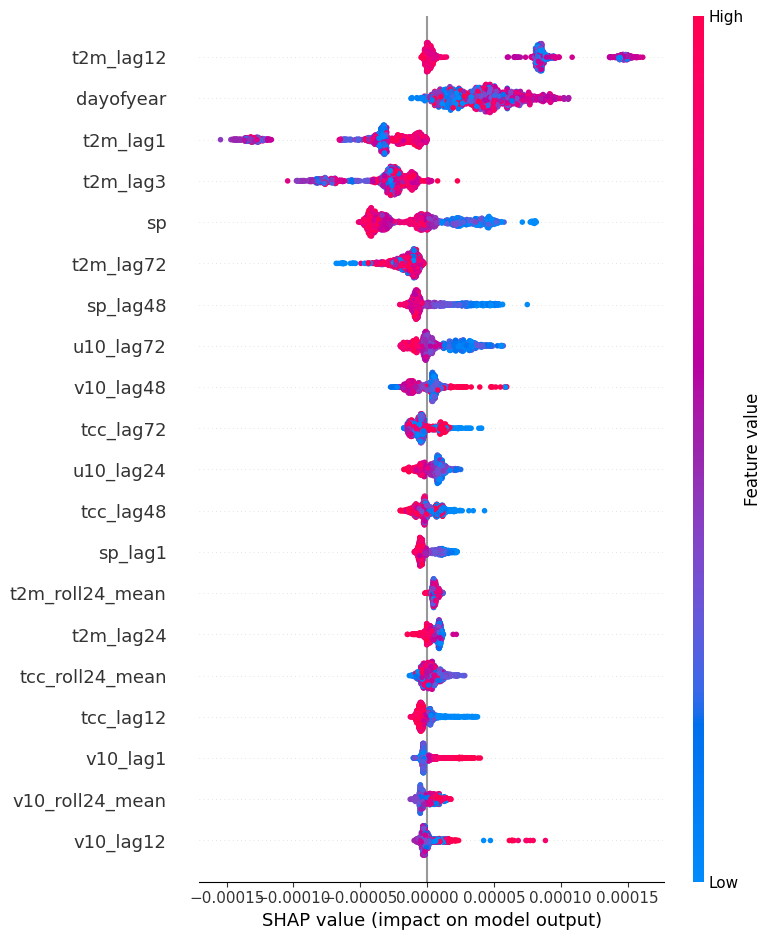

In [115]:
import shap

explainer = shap.TreeExplainer(model_grid)
shap_values = explainer.shap_values(X_val[mask_17_val])

shap.summary_plot(shap_values, X_val[mask_17_val], max_display=20)